In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Carrega o dataset limpo
df = pd.read_csv('../data/processed/dataset_clean.csv')

In [3]:
# 2. Criando o Target de Classificação (Binário)
# Vamos prever se o cliente USOU ou NÃO USOU um cupom de desconto.
df['Usou_Cupom'] = df['Coupon_Code'].apply(lambda x: 0 if x == 'Sem_Cupom' else 1)
alvo_classificacao = 'Usou_Cupom'
y = df[alvo_classificacao]

# 3. Limpeza do X (Removendo o Target, IDs e variáveis que dão a resposta na cara)
# Se deixarmos o 'Coupon_Discount', o modelo vai "colar", pois quem tem desconto de cupom > 0 obviamente usou cupom.
colunas_para_remover = [alvo_classificacao, 'Coupon_Code', 'Coupon_Discount', 'Order_ID', 'Customer_ID', 'Product_ID']
X = df.drop(columns=colunas_para_remover, errors='ignore')
X = X.select_dtypes(exclude=['object'])

/tmp/ipykernel_11122/1811806636.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tabela_importancia.head(10), x='Importancia', y='Variavel', palette='magma')


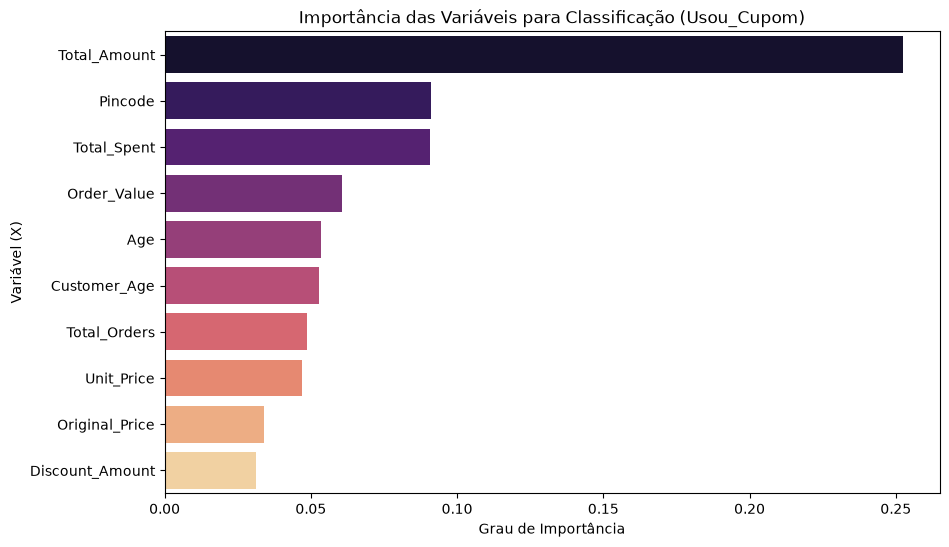

In [4]:
# 4. Treinando o modelo para extrair a importância das variáveis
modelo_classificacao = RandomForestClassifier(n_estimators=50, random_state=42)
modelo_classificacao.fit(X, y)

# 5. Gerando o ranking e o gráfico
importancias = modelo_classificacao.feature_importances_
tabela_importancia = pd.DataFrame({'Variavel': X.columns, 'Importancia': importancias}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=tabela_importancia.head(10), x='Importancia', y='Variavel', palette='magma')
plt.title('Importância das Variáveis para Classificação (Usou_Cupom)')
plt.xlabel('Grau de Importância')
plt.ylabel('Variável (X)')
plt.savefig('../reports/figures/feature_importance_classification.png', bbox_inches='tight')
plt.show()

In [6]:
# 1. Filtramos o X para manter as variáveis mais vitais descobertas no gráfico
features_selecionadas = ['Total_Amount', 'Pincode', 'Total_Spent', 'Order_Value', 'Customer_Age']
X_final_classificacao = X[features_selecionadas]

# 2. Divisão da Base: 80% para treino, 20% para teste
X_train, X_test, y_train, y_test = train_test_split(X_final_classificacao, y, test_size=0.2, random_state=42)

# 3. Construção e Treinamento do Modelo (Classificador em vez de Regressor)
modelo_final_classificacao = RandomForestClassifier(n_estimators=50, random_state=42)
modelo_final_classificacao.fit(X_train, y_train)

# 4. Avaliação de Desempenho usando a métrica de Acurácia
previsoes = modelo_final_classificacao.predict(X_test)
acuracia = accuracy_score(y_test, previsoes)

print("Pipeline de Classificação estruturado com sucesso!")
print(f"O modelo consegue prever se o cliente usou cupom com {acuracia * 100:.2f}% de exatidão.")

Pipeline de Classificação estruturado com sucesso!
O modelo consegue prever se o cliente usou cupom com 91.49% de exatidão.
